In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [14]:
## Step 1: Load and Preprocess Data
# Load training and test datasets directly from URLs
# If you have your own 'trainset.csv' and 'testset.csv', upload them to Colab or specify the correct path.
# For now, using example datasets from /content/sample_data/
df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

In [15]:
df_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


# New section

In [16]:
# Use a relevant numerical column, e.g., 'median_house_value'
train_prices = df_train['median_house_value'].values.reshape(-1, 1)
test_prices = df_test['median_house_value'].values.reshape(-1, 1)

In [17]:
# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [18]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [19]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((16940, 60, 1), (16940, 1), (2940, 60, 1), (2940, 1))

In [20]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [21]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [23]:
## Step 2: Define RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(RNNModel, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)          # RNN output
        out = self.fc(out[:, -1, :]) # Take last time step
        return out


In [24]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [25]:
!pip install torchinfo

In [26]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [27]:
criterion =nn.MSELoss()
optimizer =torch.optim.Adam(model.parameters(),lr=0.001)

In [28]:
## Step 3: Train the Model

# Write your code here


Epoch [1/20], Loss: 0.0304
Epoch [2/20], Loss: 0.0270
Epoch [3/20], Loss: 0.0270
Epoch [4/20], Loss: 0.0272
Epoch [5/20], Loss: 0.0270
Epoch [6/20], Loss: 0.0267
Epoch [7/20], Loss: 0.0269
Epoch [8/20], Loss: 0.0268
Epoch [9/20], Loss: 0.0268
Epoch [10/20], Loss: 0.0267
Epoch [11/20], Loss: 0.0268
Epoch [12/20], Loss: 0.0269
Epoch [13/20], Loss: 0.0268
Epoch [14/20], Loss: 0.0265
Epoch [15/20], Loss: 0.0267
Epoch [16/20], Loss: 0.0266
Epoch [17/20], Loss: 0.0267
Epoch [18/20], Loss: 0.0267
Epoch [19/20], Loss: 0.0265
Epoch [20/20], Loss: 0.0265
Name:Sameer Shariff M
Register Number:212224220085


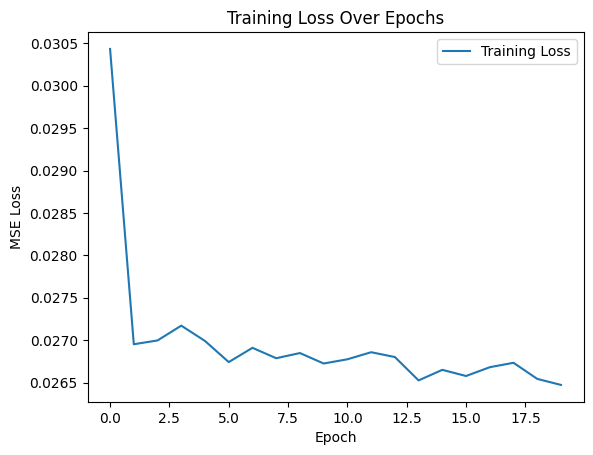

In [29]:
# Training Loop
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    train_losses = []
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()          # Clear previous gradients
            outputs = model(x_batch)       # Forward pass
            loss = criterion(outputs, y_batch)   # Compute loss

            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights

            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        print(f'Epoch [{epoch+1}/{epochs}], '
              f'Loss: {total_loss / len(train_loader):.4f}')

    # Plot training loss
    print('Name:Sameer Shariff M')
    print('Register Number:212224220085')

    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss Over Epochs')
    plt.legend()
    plt.show()

train_model(model, train_loader, criterion, optimizer)

Name:Sameer Shariff M
Register Number:212224220085


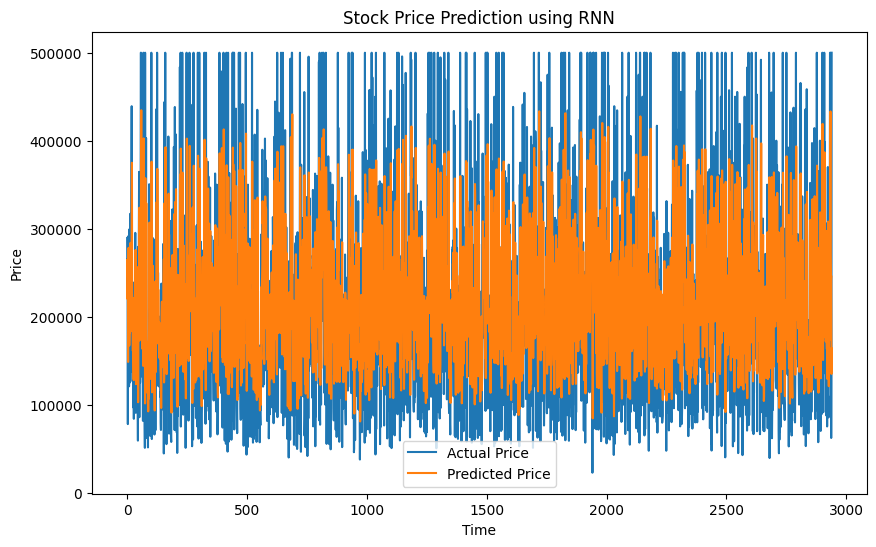

Predicted Price: [163820.66]
Actual Price: [500001.]


In [30]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

# Plot the predictions vs actual prices
print('Name:Sameer Shariff M')
print('Register Number:212224220085')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')